In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [3]:
%pip install pandas

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 932.9 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/9.8 MB 932.9 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.8 MB 1.0 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.8 MB 1.1 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.8 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.8 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.8 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.8 MB 979.0 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.8 MB 1.0 MB/s eta 0:00:08
   --------- ----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install pillow

In [11]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/8.2 MB 2.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.2 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.2 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.2 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.2 MB 1.2 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.2 MB 981.2 kB/s eta 0:00:07
   ----------- ----------------------

In [13]:
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import json
import os

DATA_DIR = Path("../data/raw/DAFA_LS")

print("Main files/folders:")
for item in DATA_DIR.iterdir():
    print(item.name)

Main files/folders:
fold_dict.json
LICENSE.txt
looted
preserved
README.txt


In [14]:
looted_dir = DATA_DIR / "looted"
preserved_dir = DATA_DIR / "preserved"

print("Looted examples:")
for item in list(looted_dir.iterdir())[:5]:
    print(item)

print("\nPreserved examples:")
for item in list(preserved_dir.iterdir())[:5]:
    print(item)

Looted examples:
..\data\raw\DAFA_LS\looted\0
..\data\raw\DAFA_LS\looted\1
..\data\raw\DAFA_LS\looted\10
..\data\raw\DAFA_LS\looted\100
..\data\raw\DAFA_LS\looted\101

Preserved examples:
..\data\raw\DAFA_LS\preserved\0
..\data\raw\DAFA_LS\preserved\1
..\data\raw\DAFA_LS\preserved\10
..\data\raw\DAFA_LS\preserved\100
..\data\raw\DAFA_LS\preserved\101


In [15]:
records = []

for class_name, label in [("preserved", 0), ("looted", 1)]:
    class_dir = DATA_DIR / class_name
    
    for site_folder in class_dir.iterdir():
        if site_folder.is_dir():
            records.append({
                "site_id": site_folder.name,
                "class_name": class_name,
                "label": label,
                "site_path": str(site_folder)
            })

labels_df = pd.DataFrame(records)

print(labels_df.head())
print(labels_df["class_name"].value_counts())

labels_df.to_csv("../data/processed/labels.csv", index=False)

  site_id class_name  label                          site_path
0       0  preserved      0    ..\data\raw\DAFA_LS\preserved\0
1       1  preserved      0    ..\data\raw\DAFA_LS\preserved\1
2      10  preserved      0   ..\data\raw\DAFA_LS\preserved\10
3     100  preserved      0  ..\data\raw\DAFA_LS\preserved\100
4     101  preserved      0  ..\data\raw\DAFA_LS\preserved\101
class_name
preserved    540
looted       135
Name: count, dtype: int64


In [16]:
image_extensions = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

metadata_records = []

for _, row in labels_df.iterrows():
    site_path = Path(row["site_path"])
    
    frames = []
    for ext in image_extensions:
        frames.extend(list(site_path.glob(f"*{ext}")))
    
    frames = sorted(frames)
    
    for idx, frame_path in enumerate(frames):
        metadata_records.append({
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_index": idx,
            "frame_name": frame_path.name,
            "frame_path": str(frame_path)
        })

metadata_df = pd.DataFrame(metadata_records)

print(metadata_df.head())
print("Total images:", len(metadata_df))
print("Total sites:", metadata_df["site_id"].nunique())

metadata_df.to_csv("../data/processed/metadata.csv", index=False)

  site_id class_name  label  frame_index   frame_name  \
0       0  preserved      0            0  2016_01.jpg   
1       0  preserved      0            1  2016_02.jpg   
2       0  preserved      0            2  2016_03.jpg   
3       0  preserved      0            3  2016_04.jpg   
4       0  preserved      0            4  2016_05.jpg   

                                    frame_path  
0  ..\data\raw\DAFA_LS\preserved\0\2016_01.jpg  
1  ..\data\raw\DAFA_LS\preserved\0\2016_02.jpg  
2  ..\data\raw\DAFA_LS\preserved\0\2016_03.jpg  
3  ..\data\raw\DAFA_LS\preserved\0\2016_04.jpg  
4  ..\data\raw\DAFA_LS\preserved\0\2016_05.jpg  
Total images: 64114
Total sites: 540


In [17]:
frame_count_df = metadata_df.groupby(["site_id", "class_name", "label"]).size().reset_index(name="total_frames")

print(frame_count_df.head())
print(frame_count_df["total_frames"].describe())

print("\nMinimum frames:")
print(frame_count_df["total_frames"].min())

print("\nSites with less than 8 frames:")
print(frame_count_df[frame_count_df["total_frames"] < 8])

  site_id class_name  label  total_frames
0       0     looted      1            96
1       0  preserved      0            96
2       1     looted      1            95
3       1  preserved      0            96
4      10     looted      1            96
count    675.000000
mean      94.983704
std        1.805375
min       82.000000
25%       95.000000
50%       95.000000
75%       96.000000
max       96.000000
Name: total_frames, dtype: float64

Minimum frames:
82

Sites with less than 8 frames:
Empty DataFrame
Columns: [site_id, class_name, label, total_frames]
Index: []


In [18]:
inventory = []

for _, row in labels_df.iterrows():
    site_path = Path(row["site_path"])
    
    frames = []
    for ext in image_extensions:
        frames.extend(list(site_path.glob(f"*{ext}")))
    
    frames = sorted(frames)
    
    if len(frames) == 0:
        inventory.append({
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "total_frames": 0,
            "first_frame": None,
            "last_frame": None,
            "image_width": None,
            "image_height": None
        })
        continue
    
    img = Image.open(frames[0]).convert("RGB")
    width, height = img.size
    
    inventory.append({
        "site_id": row["site_id"],
        "class_name": row["class_name"],
        "label": row["label"],
        "total_frames": len(frames),
        "first_frame": frames[0].name,
        "last_frame": frames[-1].name,
        "image_width": width,
        "image_height": height
    })

inventory_df = pd.DataFrame(inventory)

print(inventory_df.head())
print(inventory_df["class_name"].value_counts())
print(inventory_df["total_frames"].describe())

inventory_df.to_csv("../data/processed/data_inventory.csv", index=False)

  site_id class_name  label  total_frames  first_frame last_frame  \
0       0  preserved      0            96  2016_01.jpg   mask.png   
1       1  preserved      0            96  2016_01.jpg   mask.png   
2      10  preserved      0            95  2016_01.jpg   mask.png   
3     100  preserved      0            96  2016_01.jpg   mask.png   
4     101  preserved      0            96  2016_01.jpg   mask.png   

   image_width  image_height  
0          266           266  
1          266           266  
2          266           266  
3          266           266  
4          266           266  
class_name
preserved    540
looted       135
Name: count, dtype: int64
count    675.000000
mean      94.983704
std        1.805375
min       82.000000
25%       95.000000
50%       95.000000
75%       96.000000
max       96.000000
Name: total_frames, dtype: float64


In [19]:
bad_images = []

for _, row in metadata_df.iterrows():
    img_path = Path(row["frame_path"])
    
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        bad_images.append({
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_path": str(img_path),
            "error": str(e)
        })

bad_df = pd.DataFrame(bad_images)

print("Corrupted images:", len(bad_df))

bad_df.to_csv("../data/processed/corrupted_images.csv", index=False)

Corrupted images: 0


In [21]:
from pathlib import Path
import json
import pandas as pd

DATA_DIR = Path("../data/raw/DAFA_LS")
FOLD_PATH = DATA_DIR / "fold_dict.json"

with open(FOLD_PATH, "r") as f:
    fold_dict = json.load(f)

print(fold_dict.keys())

dict_keys(['train', 'val_1', 'val_2', 'val_3', 'val_4', 'val_5', 'test'])


In [22]:
SPLIT_DIR = Path("../data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

def make_split_df(split_name):
    rows = []

    # looted = 1
    for site_id in fold_dict[split_name]["looted"]:
        rows.append({
            "site_id": str(site_id),
            "class_name": "looted",
            "label": 1,
            "site_path": str(DATA_DIR / "looted" / str(site_id))
        })

    # preserved = 0
    for site_id in fold_dict[split_name]["preserved"]:
        rows.append({
            "site_id": str(site_id),
            "class_name": "preserved",
            "label": 0,
            "site_path": str(DATA_DIR / "preserved" / str(site_id))
        })

    return pd.DataFrame(rows)

for split_name in fold_dict.keys():
    split_df = make_split_df(split_name)
    split_df.to_csv(SPLIT_DIR / f"{split_name}.csv", index=False)

    print(split_name)
    print(split_df["class_name"].value_counts())
    print()

train
class_name
preserved    460
looted        64
Name: count, dtype: int64

val_1
class_name
looted       9
preserved    9
Name: count, dtype: int64

val_2
class_name
looted       9
preserved    9
Name: count, dtype: int64

val_3
class_name
looted       9
preserved    9
Name: count, dtype: int64

val_4
class_name
looted       9
preserved    9
Name: count, dtype: int64

val_5
class_name
looted       9
preserved    9
Name: count, dtype: int64

test
class_name
preserved    35
looted       26
Name: count, dtype: int64



In [23]:
for split_name in fold_dict.keys():
    split_df = pd.read_csv(SPLIT_DIR / f"{split_name}.csv")

    missing_paths = []

    for path in split_df["site_path"]:
        if not Path(path).exists():
            missing_paths.append(path)

    print(split_name, "missing folders:", len(missing_paths))

    if len(missing_paths) > 0:
        print(missing_paths[:10])

train missing folders: 0
val_1 missing folders: 0
val_2 missing folders: 0
val_3 missing folders: 0
val_4 missing folders: 0
val_5 missing folders: 0
test missing folders: 0


In [24]:
all_rows = []

for split_name in fold_dict.keys():
    split_df = pd.read_csv(SPLIT_DIR / f"{split_name}.csv")
    split_df["split"] = split_name
    all_rows.append(split_df)

all_labels_df = pd.concat(all_rows, ignore_index=True)

Path("../data/processed").mkdir(parents=True, exist_ok=True)
all_labels_df.to_csv("../data/processed/labels_with_splits.csv", index=False)

print(all_labels_df.head())
print(all_labels_df["split"].value_counts())
print(all_labels_df.groupby(["split", "class_name"]).size())

   site_id class_name  label                     site_path  split
0        1     looted      1  ..\data\raw\DAFA_LS\looted\1  train
1        2     looted      1  ..\data\raw\DAFA_LS\looted\2  train
2        3     looted      1  ..\data\raw\DAFA_LS\looted\3  train
3        4     looted      1  ..\data\raw\DAFA_LS\looted\4  train
4        5     looted      1  ..\data\raw\DAFA_LS\looted\5  train
split
train    524
test      61
val_1     18
val_2     18
val_3     18
val_4     18
val_5     18
Name: count, dtype: int64
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64


Looted sample
Site path: ..\data\raw\DAFA_LS\looted\0
Number of frames found: 8


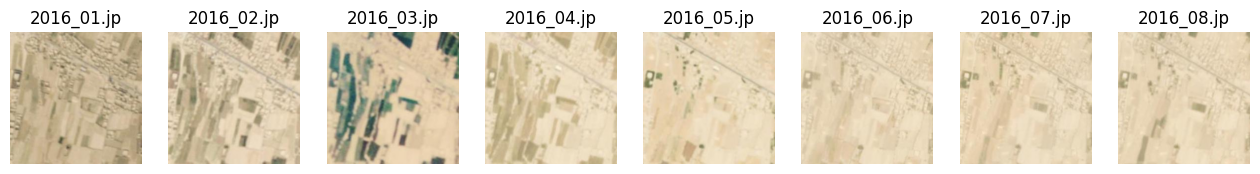

Preserved sample
Site path: ..\data\raw\DAFA_LS\preserved\0
Number of frames found: 8


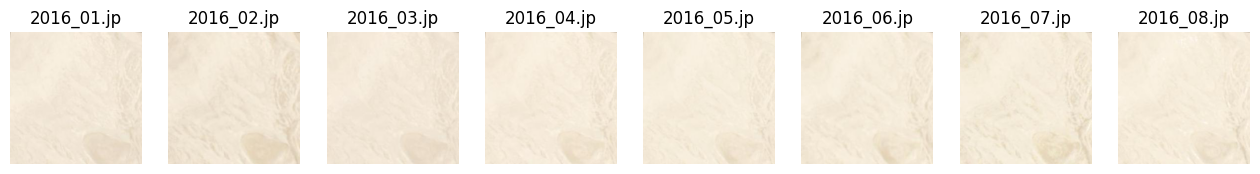

In [28]:
def show_site(site_path, n=8):
    site_path = Path(site_path)
    
    frames = []
    for ext in image_extensions:
        frames.extend(list(site_path.glob(f"*{ext}")))
    
    frames = sorted(frames)[:n]
    
    print("Site path:", site_path)
    print("Number of frames found:", len(frames))
    
    if len(frames) == 0:
        print("No images found in this folder.")
        return
    
    plt.figure(figsize=(16, 4))
    
    for i, frame in enumerate(frames):
        img = Image.open(frame).convert("RGB")
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(img)
        plt.title(frame.name[:10])
        plt.axis("off")
    
    plt.show()


looted_sample = labels_df[labels_df["label"] == 1].iloc[0]["site_path"]
preserved_sample = labels_df[labels_df["label"] == 0].iloc[0]["site_path"]

print("Looted sample")
show_site(looted_sample, n=8)

print("Preserved sample")
show_site(preserved_sample, n=8)